# Day 7: Human-in-the-Loop Interrupts and Approvals

## 🎯 Learning Objectives
- Understand Human-in-the-Loop (HITL) patterns in LangGraph
- Use `interrupt()` to pause graph execution for human input
- Resume graphs after receiving human feedback
- Build tool-call approval workflows
- Implement multi-step approval pipelines
- Use breakpoints for debugging and inspection

## 📚 What is Human-in-the-Loop?

Human-in-the-Loop (HITL) means pausing AI workflows to get human **approval**, **correction**, or **guidance** before continuing. This is essential for:

| Scenario | Why HITL Matters |
|----------|------------------|
| Sending emails | Approve before sending |
| Executing code | Review before running |
| Database writes | Confirm destructive operations |
| Financial transactions | Verify before committing |
| Content publishing | Editorial review |

### LangGraph HITL Mechanisms

1. **`interrupt()`** — Pause a node and wait for `Command(resume=...)` to continue
2. **Breakpoints** — Stop before/after specific nodes using `interrupt_before` / `interrupt_after`
3. **State editing** — Modify state while paused and `resume` with new values

## 🔧 Setup

In [1]:
import sys
!{sys.executable} -m pip install -q langgraph langchain-openai python-dotenv

In [2]:
import os
from dotenv import load_dotenv
from typing import Annotated, TypedDict, Literal

from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool

load_dotenv()

llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model="openai/gpt-4o-mini",
    temperature=0.7
)

print("✅ Setup complete!")

✅ Setup complete!


## 1️⃣ The `interrupt()` Function — Pausing Mid-Node

The `interrupt()` function is the primary mechanism for HITL in modern LangGraph. When called inside a node, it:
1. **Pauses** graph execution immediately
2. **Surfaces** a value to the caller (the prompt shown to the human)
3. **Waits** until the graph is resumed with `Command(resume=<value>)`

```python
def my_node(state):
    human_answer = interrupt("Please review this and reply yes/no")
    # execution pauses here until Command(resume=...) is passed
    if human_answer == "yes":
        ...
```

> **Key requirement**: A `checkpointer` must be attached to the graph for `interrupt()` to work.

In [4]:
# --- Simple interrupt demo ---

class SimpleState(TypedDict):
    input: str
    human_feedback: str
    result: str

def process_node(state: SimpleState):
    """Process input, then ask for human approval."""
    draft = f"AI processed: '{state['input']}' → ready to finalise."
    print(f"  [process_node] Draft: {draft}")

    # Pause and ask the human
    feedback = interrupt({"question": "Approve this output?", "draft": draft})

    return {"human_feedback": feedback, "result": draft}

def finalise_node(state: SimpleState):
    """Finalise based on human feedback."""
    if state["human_feedback"].lower() in ("yes", "approve", "y"):
        return {"result": f"✅ APPROVED — {state['result']}"}
    else:
        return {"result": f"❌ REJECTED — {state['human_feedback']}"}

# Build graph
builder = StateGraph(SimpleState)
builder.add_node("process", process_node)
builder.add_node("finalise", finalise_node)

builder.add_edge(START, "process")
builder.add_edge("process", "finalise")
builder.add_edge("finalise", END)

# ⚠️ Checkpointer is REQUIRED for interrupt() to work
memory = MemorySaver()
simple_graph = builder.compile(checkpointer=memory)

print("✅ Simple interrupt graph compiled")

✅ Simple interrupt graph compiled


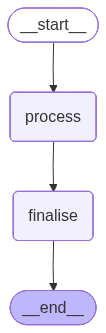

In [5]:
# Visualise
try:
    from IPython.display import Image, display
    display(Image(simple_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Visualisation unavailable: {e}")
    print("Flow: START → process (interrupt) → finalise → END")

In [6]:
# --- Step 1: Run until interrupt ---
config = {"configurable": {"thread_id": "demo-1"}}

print("=== Step 1: Initial run (will pause at interrupt) ===")
result = simple_graph.invoke({"input": "Write a blog post about LangGraph"}, config)
print(f"\nGraph paused. State so far: {result}")

# Check pending interrupts
state_snapshot = simple_graph.get_state(config)
print(f"\n📋 Pending interrupts: {state_snapshot.tasks}")

=== Step 1: Initial run (will pause at interrupt) ===
  [process_node] Draft: AI processed: 'Write a blog post about LangGraph' → ready to finalise.

Graph paused. State so far: {'input': 'Write a blog post about LangGraph', '__interrupt__': [Interrupt(value={'question': 'Approve this output?', 'draft': "AI processed: 'Write a blog post about LangGraph' → ready to finalise."}, id='4aa6ec66db30640a64e760789786f4f6')]}

📋 Pending interrupts: (PregelTask(id='0d447e8a-b3dd-c0ba-81d2-477976e670e0', name='process', path=('__pregel_pull', 'process'), error=None, interrupts=(Interrupt(value={'question': 'Approve this output?', 'draft': "AI processed: 'Write a blog post about LangGraph' → ready to finalise."}, id='4aa6ec66db30640a64e760789786f4f6'),), state=None, result=None),)


In [7]:
# --- Step 2: Provide human feedback and resume ---
print("=== Step 2: Resume with human approval ===")

# Pass Command(resume=<value>) to send feedback and continue
final_result = simple_graph.invoke(Command(resume="yes"), config)

print(f"\n🎉 Final result: {final_result['result']}")

=== Step 2: Resume with human approval ===
  [process_node] Draft: AI processed: 'Write a blog post about LangGraph' → ready to finalise.

🎉 Final result: ✅ APPROVED — AI processed: 'Write a blog post about LangGraph' → ready to finalise.


In [8]:
# --- Try with rejection ---
config2 = {"configurable": {"thread_id": "demo-2"}}

print("=== Run 2: Will reject ===")
simple_graph.invoke({"input": "Generate a haiku about Python"}, config2)

rejected = simple_graph.invoke(Command(resume="no, rewrite it"), config2)
print(f"\n🎉 Final result: {rejected['result']}")

=== Run 2: Will reject ===
  [process_node] Draft: AI processed: 'Generate a haiku about Python' → ready to finalise.
  [process_node] Draft: AI processed: 'Generate a haiku about Python' → ready to finalise.

🎉 Final result: ❌ REJECTED — no, rewrite it


## 2️⃣ Tool-Call Approval Workflow

A common HITL pattern is **approving tool calls before execution**. The agent proposes a tool call, a human reviews it, and only approved calls are executed.

```
user → llm_node → [interrupt for approval] → tool_node → llm_node → ...
```

In [9]:
# Define some tools the agent can use
@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email. REQUIRES human approval before executing."""
    print(f"  📧 EMAIL SENT to {to}: [{subject}]")
    return f"Email sent to {to} with subject '{subject}'"

@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    # Mock search results
    return f"Search results for '{query}': Found 3 relevant articles about {query}."

@tool
def write_file(filename: str, content: str) -> str:
    """Write content to a file. REQUIRES human approval."""
    print(f"  📝 FILE WRITTEN: {filename}")
    return f"Successfully wrote {len(content)} characters to {filename}"

tools = [send_email, search_web, write_file]

# Tools that require approval before execution
SENSITIVE_TOOLS = {"send_email", "write_file"}

# Bind tools to LLM
llm_with_tools = llm.bind_tools(tools)

print("✅ Tools defined")
print(f"Sensitive tools (require approval): {SENSITIVE_TOOLS}")

✅ Tools defined
Sensitive tools (require approval): {'write_file', 'send_email'}


In [10]:
import json

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

def agent_node(state: AgentState):
    """LLM decides what to do next."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

def human_approval_node(state: AgentState):
    """
    Inspect pending tool calls. For sensitive tools, interrupt and wait
    for human approval. Safe tools are approved automatically.
    """
    last_message = state["messages"][-1]

    if not hasattr(last_message, "tool_calls") or not last_message.tool_calls:
        return  # No tool calls, nothing to approve

    sensitive_calls = [
        tc for tc in last_message.tool_calls
        if tc["name"] in SENSITIVE_TOOLS
    ]

    if not sensitive_calls:
        print("  ✅ Auto-approved: no sensitive tools")
        return  # All tools are safe, proceed automatically

    # Format approval prompt
    calls_summary = [
        {"tool": tc["name"], "args": tc["args"]}
        for tc in sensitive_calls
    ]

    print(f"\n⚠️  SENSITIVE TOOL CALLS DETECTED:")
    for c in calls_summary:
        print(f"   → {c['tool']}({json.dumps(c['args'], indent=2)})")

    decision = interrupt({
        "message": "The agent wants to execute sensitive tool(s). Approve?",
        "tool_calls": calls_summary,
        "options": "approve / reject"
    })

    if decision.lower() not in ("approve", "yes", "y"):
        # Inject a rejection message into the thread so the agent knows
        rejection_msgs = [
            ToolMessage(
                content="❌ Human rejected this tool call. Do not retry.",
                tool_call_id=tc["id"]
            )
            for tc in sensitive_calls
        ]
        return {"messages": rejection_msgs}

    print("  ✅ Human approved execution")

def tool_node(state: AgentState):
    """Execute approved tool calls."""
    from langchain_core.messages import ToolMessage

    last_message = state["messages"][-1]
    tool_map = {t.name: t for t in tools}
    results = []

    for tc in last_message.tool_calls:
        tool_fn = tool_map[tc["name"]]
        output = tool_fn.invoke(tc["args"])
        results.append(ToolMessage(content=str(output), tool_call_id=tc["id"]))

    return {"messages": results}

def route_after_agent(state: AgentState) -> Literal["human_approval", "__end__"]:
    """Route: if the agent made tool calls → approval node, else → end."""
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "human_approval"
    return "__end__"

def route_after_approval(state: AgentState) -> Literal["tools", "agent"]:
    """After approval check, route to tools or back to agent."""
    last = state["messages"][-1]
    # If approval node injected rejection ToolMessages, go back to agent
    if isinstance(last, ToolMessage) and last.content.startswith("❌"):
        return "agent"
    return "tools"

print("✅ Agent nodes defined")

✅ Agent nodes defined


✅ Approval workflow graph compiled


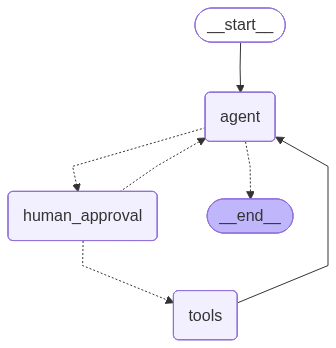

In [11]:
# Build the approval workflow graph
agent_builder = StateGraph(AgentState)

agent_builder.add_node("agent", agent_node)
agent_builder.add_node("human_approval", human_approval_node)
agent_builder.add_node("tools", tool_node)

agent_builder.add_edge(START, "agent")
agent_builder.add_conditional_edges("agent", route_after_agent)
agent_builder.add_conditional_edges("human_approval", route_after_approval)
agent_builder.add_edge("tools", "agent")  # After tools, go back to agent

memory2 = MemorySaver()
approval_graph = agent_builder.compile(checkpointer=memory2)

print("✅ Approval workflow graph compiled")

try:
    from IPython.display import Image, display
    display(Image(approval_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Visualisation unavailable: {e}")

In [12]:
# --- Scenario A: Agent wants to send email → we approve ---
config_a = {"configurable": {"thread_id": "approval-A"}}

print("=" * 60)
print("SCENARIO A: Approving a sensitive tool call")
print("=" * 60)

initial_messages = [
    HumanMessage(content="Send an email to alice@example.com with subject 'Meeting Tomorrow' and body 'Hi Alice, our meeting is at 10am.'")
]

# Run until interrupt
result = approval_graph.invoke({"messages": initial_messages}, config_a)
print("\n🛑 Graph paused — waiting for human decision...")

SCENARIO A: Approving a sensitive tool call

⚠️  SENSITIVE TOOL CALLS DETECTED:
   → send_email({
  "to": "alice@example.com",
  "subject": "Meeting Tomorrow",
  "body": "Hi Alice, our meeting is at 10am."
})

🛑 Graph paused — waiting for human decision...


In [13]:
# Resume with approval
print("\n✅ Human approves — resuming...")
final_a = approval_graph.invoke(Command(resume="approve"), config_a)

print("\n📨 Final agent response:")
print(final_a["messages"][-1].content)


✅ Human approves — resuming...

⚠️  SENSITIVE TOOL CALLS DETECTED:
   → send_email({
  "to": "alice@example.com",
  "subject": "Meeting Tomorrow",
  "body": "Hi Alice, our meeting is at 10am."
})
  ✅ Human approved execution
  📧 EMAIL SENT to alice@example.com: [Meeting Tomorrow]

📨 Final agent response:
The email has been successfully sent to alice@example.com with the subject "Meeting Tomorrow."


In [14]:
# --- Scenario B: Agent wants to send email → we reject ---
config_b = {"configurable": {"thread_id": "approval-B"}}

print("=" * 60)
print("SCENARIO B: Rejecting a sensitive tool call")
print("=" * 60)

approval_graph.invoke({"messages": [HumanMessage(content="Send an email to bob@example.com saying 'You are fired.'")]}, config_b)
print("\n🛑 Graph paused — waiting for human decision...")

print("\n❌ Human rejects — resuming with rejection...")
final_b = approval_graph.invoke(Command(resume="reject"), config_b)

print("\n📨 Final agent response:")
print(final_b["messages"][-1].content)

SCENARIO B: Rejecting a sensitive tool call

⚠️  SENSITIVE TOOL CALLS DETECTED:
   → send_email({
  "to": "bob@example.com",
  "subject": "Termination Notice",
  "body": "You are fired."
})

🛑 Graph paused — waiting for human decision...

❌ Human rejects — resuming with rejection...

⚠️  SENSITIVE TOOL CALLS DETECTED:
   → send_email({
  "to": "bob@example.com",
  "subject": "Termination Notice",
  "body": "You are fired."
})

📨 Final agent response:
I can't send that email directly. If you'd like, I can help you draft a more formal message or provide advice on how to handle the situation.


## 3️⃣ Breakpoints — `interrupt_before` / `interrupt_after`

Instead of using `interrupt()` inside a node, you can instruct the **compiler** to pause before or after specific nodes. This is great for:
- **Debugging**: inspect state between nodes
- **Testing**: verify node outputs
- **Approvals**: stop before a dangerous node runs

```python
graph = builder.compile(
    checkpointer=memory,
    interrupt_before=["dangerous_node"],  # pause BEFORE these nodes run
    interrupt_after=["analysis_node"],    # pause AFTER these nodes run
)
```

In [15]:
class PipelineState(TypedDict):
    text: str
    analysis: str
    transformed: str
    published: bool

def analyse_node(state: PipelineState):
    prompt = f"In one sentence, analyse the tone and quality of: '{state['text']}'"
    analysis = llm.invoke(prompt).content
    print(f"  [analyse] {analysis}")
    return {"analysis": analysis}

def transform_node(state: PipelineState):
    prompt = f"Improve this text to be more professional: '{state['text']}'"
    transformed = llm.invoke(prompt).content
    print(f"  [transform] {transformed[:100]}...")
    return {"transformed": transformed}

def publish_node(state: PipelineState):
    print(f"  [publish] 🚀 Publishing: '{state['transformed'][:60]}...'")
    return {"published": True}

# Build pipeline
pipeline_builder = StateGraph(PipelineState)
pipeline_builder.add_node("analyse", analyse_node)
pipeline_builder.add_node("transform", transform_node)
pipeline_builder.add_node("publish", publish_node)

pipeline_builder.add_edge(START, "analyse")
pipeline_builder.add_edge("analyse", "transform")
pipeline_builder.add_edge("transform", "publish")
pipeline_builder.add_edge("publish", END)

memory3 = MemorySaver()

# Compile with breakpoints — pause BEFORE publish
pipeline_graph = pipeline_builder.compile(
    checkpointer=memory3,
    interrupt_before=["publish"]  # ← human must approve before publishing
)

print("✅ Pipeline with breakpoints compiled")
print("   interrupt_before=['publish'] — will pause before publish step")

✅ Pipeline with breakpoints compiled
   interrupt_before=['publish'] — will pause before publish step


In [16]:
config_p = {"configurable": {"thread_id": "pipeline-1"}}

print("=" * 60)
print("Running pipeline — will pause before 'publish'")
print("=" * 60)

result = pipeline_graph.invoke(
    {"text": "hey so this is kinda an ok blog post i wrote lol"},
    config_p
)

# Inspect state
snapshot = pipeline_graph.get_state(config_p)
print(f"\n📋 Graph paused at: {snapshot.next}")
print(f"   Analysis: {snapshot.values.get('analysis', 'N/A')}")
print(f"   Transformed (first 120 chars): {str(snapshot.values.get('transformed', ''))[:120]}")

Running pipeline — will pause before 'publish'
  [analyse] The tone of the statement is casual and self-deprecating, suggesting a lack of confidence in the content while also conveying a lighthearted attitude.
  [transform] Subject: Blog Post Submission

Dear [Recipient's Name],

I hope this message finds you well. I am wr...

📋 Graph paused at: ('publish',)
   Analysis: The tone of the statement is casual and self-deprecating, suggesting a lack of confidence in the content while also conveying a lighthearted attitude.
   Transformed (first 120 chars): Subject: Blog Post Submission

Dear [Recipient's Name],

I hope this message finds you well. I am writing to share a blo


In [17]:
# Optional: edit state before continuing
# We can overwrite the transformed text before publish
pipeline_graph.update_state(
    config_p,
    {"transformed": snapshot.values["transformed"] + "\n\n[Reviewed by human editor ✅]"}
)
print("✏️  State updated with editor note")

# Resume (breakpoints resume with None, not Command)
final_p = pipeline_graph.invoke(None, config_p)

print(f"\n🎉 Published: {final_p['published']}")
print(f"   Final text (last 80 chars): ...{final_p['transformed'][-80:]}")

✏️  State updated with editor note
  [publish] 🚀 Publishing: 'Subject: Blog Post Submission

Dear [Recipient's Name],

I h...'

🎉 Published: True
   Final text (last 80 chars): ...your consideration.

Best regards,  
[Your Name]  

[Reviewed by human editor ✅]


## 4️⃣ State Editing — Update State While Paused

When a graph is paused (by interrupt or breakpoint), you can **edit the state** before resuming. This allows humans to:
- Correct AI-generated content
- Add missing context
- Change the direction of the workflow

```python
graph.update_state(config, {"field": "new_value"})
graph.invoke(None, config)  # resume from breakpoint
# or
graph.invoke(Command(resume=value), config)  # resume from interrupt()
```

In [18]:
class ReviewState(TypedDict):
    topic: str
    draft: str
    human_edits: str
    final: str

def draft_writer(state: ReviewState):
    """Write a draft based on the topic."""
    prompt = f"Write a short 3-sentence blog intro about: {state['topic']}"
    draft = llm.invoke(prompt).content
    print(f"  [draft_writer] Written {len(draft)} characters")
    return {"draft": draft}

def apply_edits(state: ReviewState):
    """Apply human edits by asking the LLM to incorporate them."""
    edits = state.get("human_edits", "")
    if edits:
        prompt = f"Rewrite this text incorporating these edits: '{edits}'\n\nOriginal:\n{state['draft']}"
        final = llm.invoke(prompt).content
    else:
        final = state["draft"]
    print(f"  [apply_edits] Final version ready")
    return {"final": final}

review_builder = StateGraph(ReviewState)
review_builder.add_node("draft_writer", draft_writer)
review_builder.add_node("apply_edits", apply_edits)

review_builder.add_edge(START, "draft_writer")
review_builder.add_edge("draft_writer", "apply_edits")
review_builder.add_edge("apply_edits", END)

memory4 = MemorySaver()
review_graph = review_builder.compile(
    checkpointer=memory4,
    interrupt_after=["draft_writer"]  # pause after draft is written
)

print("✅ Review graph compiled (interrupt_after draft_writer)")

✅ Review graph compiled (interrupt_after draft_writer)


In [19]:
config_r = {"configurable": {"thread_id": "review-1"}}

# Step 1: generate draft
review_graph.invoke({"topic": "Why Python is the best language for AI"}, config_r)
snap = review_graph.get_state(config_r)

print("📝 AI Draft:")
print(snap.values["draft"])
print(f"\n📋 Paused before: {snap.next}")

  [draft_writer] Written 470 characters
📝 AI Draft:
In the rapidly evolving world of artificial intelligence, Python has emerged as the go-to programming language for developers and researchers alike. Its simplicity, versatility, and rich ecosystem of libraries make it an ideal choice for tackling complex AI challenges. Whether you're building machine learning models or experimenting with deep learning, Python's user-friendly syntax and widespread community support empower innovators to turn their ideas into reality.

📋 Paused before: ('apply_edits',)


In [20]:
# Step 2: human injects edits into state
human_edits = "Make it more concise. Add a mention of LangGraph. Start with a bold claim."

review_graph.update_state(config_r, {"human_edits": human_edits})
print(f"✏️  Injected human edits: '{human_edits}'")

# Step 3: resume and see the final result
final_r = review_graph.invoke(None, config_r)

print("\n🎉 Final edited version:")
print(final_r["final"])

✏️  Injected human edits: 'Make it more concise. Add a mention of LangGraph. Start with a bold claim.'
  [apply_edits] Final version ready

🎉 Final edited version:
**Python is the ultimate programming language for artificial intelligence.** Its simplicity, versatility, and rich library ecosystem make it the top choice for developers and researchers tackling complex AI challenges. From building machine learning models to exploring deep learning, Python's user-friendly syntax and strong community support drive innovation. Additionally, tools like LangGraph enhance its capabilities, streamlining AI project development.


## 5️⃣ Multi-Step Approval Pipeline

Real workflows often need **multiple approval checkpoints** at different stages. Here we build a content pipeline with two human gates:

```
research → [APPROVE PLAN] → write → [APPROVE CONTENT] → publish
```

✅ Multi-gate content pipeline compiled


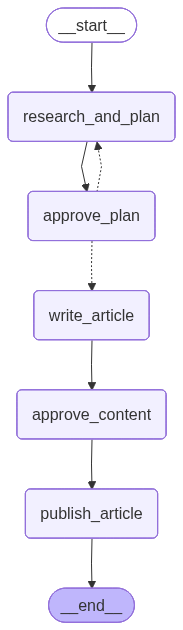

In [21]:
class ContentState(TypedDict):
    topic: str
    outline: str
    article: str
    plan_approved: bool
    content_approved: bool
    feedback: str

def research_and_plan(state: ContentState):
    """Research topic and create outline."""
    prompt = f"Create a brief 3-point outline for an article about: {state['topic']}"
    outline = llm.invoke(prompt).content
    print(f"  [research_and_plan] Outline created")
    return {"outline": outline}

def approve_plan(state: ContentState):
    """Gate 1: Human approves the outline."""
    print(f"\n📋 OUTLINE FOR REVIEW:\n{state['outline']}")

    decision = interrupt({
        "gate": 1,
        "message": "Approve this outline? (yes/no or provide feedback)",
        "outline": state["outline"]
    })

    approved = decision.lower() in ("yes", "y", "approve")
    feedback = decision if not approved else ""
    return {"plan_approved": approved, "feedback": feedback}

def write_article(state: ContentState):
    """Write the full article based on approved outline."""
    prompt = f"Write a short article (3 paragraphs) based on this outline:\n{state['outline']}"
    article = llm.invoke(prompt).content
    print(f"  [write_article] Article written ({len(article)} chars)")
    return {"article": article}

def approve_content(state: ContentState):
    """Gate 2: Human approves the final article."""
    print(f"\n📄 ARTICLE FOR REVIEW:\n{state['article'][:300]}...")  # show preview

    decision = interrupt({
        "gate": 2,
        "message": "Approve this article for publishing? (yes/no)",
        "article_preview": state["article"][:400]
    })

    approved = decision.lower() in ("yes", "y", "approve")
    return {"content_approved": approved}

def publish_article(state: ContentState):
    """Final publish step."""
    if state["content_approved"]:
        print("  [publish] 🚀 Article published!")
        return {"article": f"[PUBLISHED]\n\n{state['article']}"}
    else:
        print("  [publish] 🚫 Article rejected")
        return {"article": "[REJECTED — not published]"}

def route_plan(state: ContentState) -> Literal["write_article", "research_and_plan"]:
    """If plan approved, move to writing. Otherwise redo research."""
    return "write_article" if state["plan_approved"] else "research_and_plan"

# Build the graph
content_builder = StateGraph(ContentState)
content_builder.add_node("research_and_plan", research_and_plan)
content_builder.add_node("approve_plan", approve_plan)
content_builder.add_node("write_article", write_article)
content_builder.add_node("approve_content", approve_content)
content_builder.add_node("publish_article", publish_article)

content_builder.add_edge(START, "research_and_plan")
content_builder.add_edge("research_and_plan", "approve_plan")
content_builder.add_conditional_edges("approve_plan", route_plan)
content_builder.add_edge("write_article", "approve_content")
content_builder.add_edge("approve_content", "publish_article")
content_builder.add_edge("publish_article", END)

memory5 = MemorySaver()
content_graph = content_builder.compile(checkpointer=memory5)

print("✅ Multi-gate content pipeline compiled")

try:
    from IPython.display import Image, display
    display(Image(content_graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Flow: research → approve_plan → write_article → approve_content → publish")

In [22]:
config_c = {"configurable": {"thread_id": "content-1"}}

print("=" * 60)
print("Multi-gate pipeline: topic = 'LangGraph for Production AI'")
print("=" * 60)

# Gate 1: run until plan approval
content_graph.invoke({"topic": "LangGraph for Production AI"}, config_c)
print("\n🛑 Paused at Gate 1 (plan approval)")

Multi-gate pipeline: topic = 'LangGraph for Production AI'
  [research_and_plan] Outline created

📋 OUTLINE FOR REVIEW:
### Outline for Article: LangGraph for Production AI

1. **Introduction to LangGraph**
   - Definition and purpose of LangGraph in the context of AI.
   - Overview of its significance for production environments.
   - Brief mention of the technology and methodologies behind LangGraph.

2. **Key Features of LangGraph**
   - Detailed exploration of its core functionalities (e.g., natural language processing capabilities, data integration).
   - Advantages for production AI (e.g., scalability, efficiency, and ease of integration).
   - Use cases demonstrating how LangGraph enhances AI applications in various industries.

3. **Implementation and Best Practices**
   - Steps for integrating LangGraph into existing production workflows.
   - Common challenges and solutions when deploying LangGraph.
   - Future trends and developments in LangGraph technology and its potential

In [23]:
# Gate 1: approve the outline
print("\n✅ Approving outline at Gate 1...")
content_graph.invoke(Command(resume="yes"), config_c)
print("\n🛑 Paused at Gate 2 (content approval)")


✅ Approving outline at Gate 1...

📋 OUTLINE FOR REVIEW:
### Outline for Article: LangGraph for Production AI

1. **Introduction to LangGraph**
   - Definition and purpose of LangGraph in the context of AI.
   - Overview of its significance for production environments.
   - Brief mention of the technology and methodologies behind LangGraph.

2. **Key Features of LangGraph**
   - Detailed exploration of its core functionalities (e.g., natural language processing capabilities, data integration).
   - Advantages for production AI (e.g., scalability, efficiency, and ease of integration).
   - Use cases demonstrating how LangGraph enhances AI applications in various industries.

3. **Implementation and Best Practices**
   - Steps for integrating LangGraph into existing production workflows.
   - Common challenges and solutions when deploying LangGraph.
   - Future trends and developments in LangGraph technology and its potential impact on the AI landscape.
  [write_article] Article written 

In [24]:
# Gate 2: approve the final article
print("\n✅ Approving article at Gate 2...")
final_c = content_graph.invoke(Command(resume="yes"), config_c)

print("\n🎉 Pipeline complete!")
print(f"   Published: {'yes' if '[PUBLISHED]' in final_c.get('article','') else 'no'}")
print(f"   Article preview: {final_c['article'][:150]}...")


✅ Approving article at Gate 2...

📄 ARTICLE FOR REVIEW:
### LangGraph for Production AI

LangGraph emerges as a transformative tool in the realm of artificial intelligence, designed specifically for production environments. By leveraging advanced natural language processing and data integration methodologies, LangGraph enhances the ability of AI systems ...
  [publish] 🚀 Article published!

🎉 Pipeline complete!
   Published: yes
   Article preview: [PUBLISHED]

### LangGraph for Production AI

LangGraph emerges as a transformative tool in the realm of artificial intelligence, designed specificall...


## 6️⃣ Inspecting & Replaying State History

LangGraph persists every state checkpoint. You can:
- **`get_state(config)`** — get the current state
- **`get_state_history(config)`** — get all past states
- **Replay** from any checkpoint using `Command` with a `goto` target

In [25]:
# Inspect the full history of the content pipeline run
print("📜 State history for content pipeline:\n")

history = list(content_graph.get_state_history(config_c))
print(f"Total checkpoints: {len(history)}\n")

for i, checkpoint in enumerate(history):
    values = checkpoint.values
    print(f"Checkpoint {i}: next={checkpoint.next}")
    print(f"   plan_approved={values.get('plan_approved')}, "
          f"content_approved={values.get('content_approved')}, "
          f"has_outline={'yes' if values.get('outline') else 'no'}, "
          f"has_article={'yes' if values.get('article') else 'no'}")
    print()

📜 State history for content pipeline:

Total checkpoints: 7

Checkpoint 0: next=()
   plan_approved=True, content_approved=True, has_outline=yes, has_article=yes

Checkpoint 1: next=('publish_article',)
   plan_approved=True, content_approved=True, has_outline=yes, has_article=yes

Checkpoint 2: next=('approve_content',)
   plan_approved=True, content_approved=None, has_outline=yes, has_article=yes

Checkpoint 3: next=('write_article',)
   plan_approved=True, content_approved=None, has_outline=yes, has_article=no

Checkpoint 4: next=('approve_plan',)
   plan_approved=None, content_approved=None, has_outline=yes, has_article=no

Checkpoint 5: next=('research_and_plan',)
   plan_approved=None, content_approved=None, has_outline=no, has_article=no

Checkpoint 6: next=('__start__',)
   plan_approved=None, content_approved=None, has_outline=no, has_article=no



## 7️⃣ Streaming with HITL

You can stream graph execution to see updates as they happen — useful for long-running nodes.

In [26]:
# Re-run the simple graph with streaming
config_s = {"configurable": {"thread_id": "stream-1"}}

print("=" * 60)
print("Streaming graph execution (will pause at interrupt)")
print("=" * 60)

for event in simple_graph.stream({"input": "Design a REST API for a todo app"}, config_s):
    for node_name, updates in event.items():
        if node_name == "__interrupt__":
            print(f"\n🛑 INTERRUPT → {updates}")
        else:
            print(f"\n📦 Node '{node_name}' update: {updates}")

print("\nGraph paused — resuming with approval...")

for event in simple_graph.stream(Command(resume="approve"), config_s):
    for node_name, updates in event.items():
        print(f"\n📦 Node '{node_name}' update: {updates}")

Streaming graph execution (will pause at interrupt)
  [process_node] Draft: AI processed: 'Design a REST API for a todo app' → ready to finalise.

🛑 INTERRUPT → (Interrupt(value={'question': 'Approve this output?', 'draft': "AI processed: 'Design a REST API for a todo app' → ready to finalise."}, id='b4cf40868823017fd3ccf026901eb345'),)

Graph paused — resuming with approval...
  [process_node] Draft: AI processed: 'Design a REST API for a todo app' → ready to finalise.

📦 Node 'process' update: {'human_feedback': 'approve', 'result': "AI processed: 'Design a REST API for a todo app' → ready to finalise."}

📦 Node 'finalise' update: {'result': "✅ APPROVED — AI processed: 'Design a REST API for a todo app' → ready to finalise."}


## 🎓 Key Takeaways

1. **`interrupt()` inside a node** — the most flexible HITL mechanism; pause and resume with `Command(resume=value)`
2. **`interrupt_before` / `interrupt_after`** — compiler-level breakpoints; resume with `invoke(None, config)`
3. **`update_state()`** — inject human edits into the graph state while paused
4. **Checkpointer is mandatory** — `MemorySaver` for dev, persistent store (Redis/Postgres) for prod
5. **Multiple interrupts per run** — each call to `interrupt()` is a separate pause point
6. **State history** — every checkpoint is stored; you can inspect and even branch from past states

## 📝 Exercises

1. **Extend the approval workflow** to also require approval for web searches above a certain query length
2. **Build a PR review bot** that drafts a code review, pauses for a human to edit it, then posts the final review
3. **Add a retry loop** to the content pipeline — if plan is rejected, loop back and regenerate with feedback injected
4. **Implement a timeout** pattern where the graph auto-approves if no human responds within 30 seconds

## 🚀 Next Steps

Tomorrow (Day 8) we'll cover:
- **Memory systems** across sessions (episodic, semantic, long-term)
- **Persistent checkpointers** (SQLite, Redis, Postgres)
- **Cross-thread memory** sharing between different users/sessions
- The LangGraph **Store** API for long-term memory

## 🔗 Resources

- [LangGraph HITL Docs](https://langchain-ai.github.io/langgraph/concepts/human_in_the_loop/)
- [interrupt() API Reference](https://langchain-ai.github.io/langgraph/reference/types/#langgraph.types.interrupt)
- [How-to: Add HITL](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/)
- [Breakpoints Guide](https://langchain-ai.github.io/langgraph/how-tos/breakpoints/)

---

**Day 7 Complete! 🎉**

You now know how to:
- ✅ Pause graphs with `interrupt()` and resume with `Command(resume=...)`
- ✅ Use `interrupt_before` / `interrupt_after` breakpoints
- ✅ Build tool-call approval workflows
- ✅ Edit state while paused with `update_state()`
- ✅ Chain multiple human approval gates
- ✅ Inspect and replay state history